### Roles to explore

In [14]:

# Import Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns


# Load Dataset
dataset = load_dataset('Sumedchakma/jobs_record')
df = dataset['train'].to_pandas()



# Data Cleaning
# -------------------------------

# Convert job_posted_date to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from string to list
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Repo card metadata block was not found. Setting CardData to empty.


### US Data Analyst role filtration

In [17]:
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


In [18]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & 
              (df['job_country'] == 'United States')]


### Plotting in BAR plot

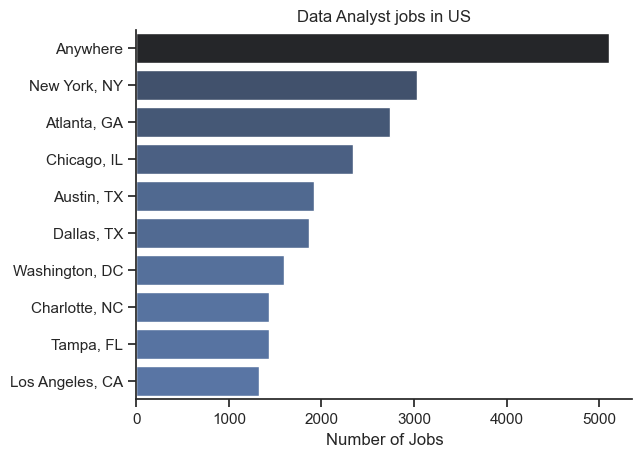

In [29]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

df_plot = df_plot.reset_index()
df_plot.columns = ['job_location', 'count']

sns.set_theme(style='ticks')


sns.barplot(
    data=df_plot,
    x='count',
    y='job_location',
    hue='count',
    palette='dark:b_r',
    legend=False
)

sns.despine()

plt.title('Data Analyst jobs in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

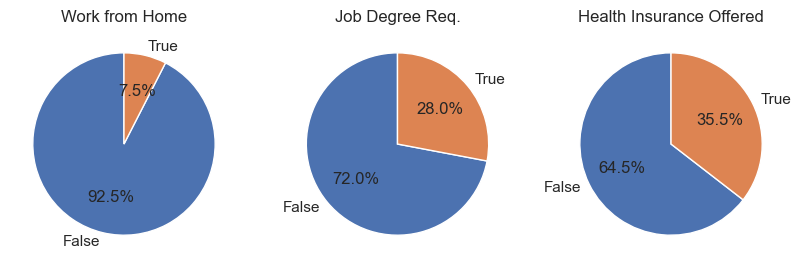

In [23]:
fig, ax = plt.subplots(1, 3, figsize = (10,8))

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}
for i, (column, title) in enumerate(dict_column.items()):

    ax[i].pie(
        df_DA_US[column].value_counts(),
        startangle=90,
        autopct='%1.1f%%',
        labels=['False', 'True']
    )

    ax[i].set_title(title)

plt.show()

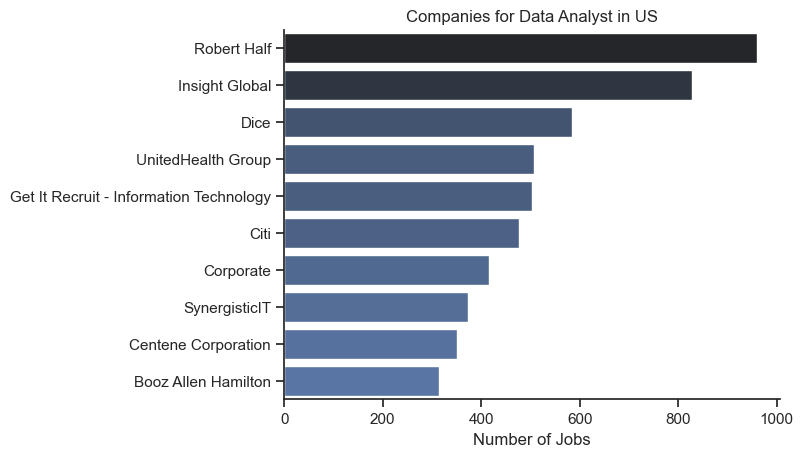

In [26]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

df_plot = df_plot.reset_index()
df_plot.columns = ['company_name', 'count']

sns.set_theme(style='ticks')

sns.barplot(
    data=df_plot,
    x='count',
    y='company_name',
    hue='count',
    palette='dark:b_r',
    legend=False
)

sns.despine()

plt.title('Companies for Data Analyst in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()